# BRAT Classification
### Final Project CS273P
BRAT = bread + cat

**The ML problem:**
Classifying between cat and cat-loaf images.

In [ ]:
!pip install torch torchvision scikit-learn matplotlib seaborn numpy pillow tqdm

### Load data

Classes found: ['cat', 'loaf']


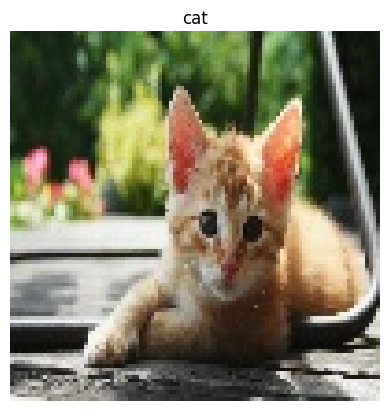

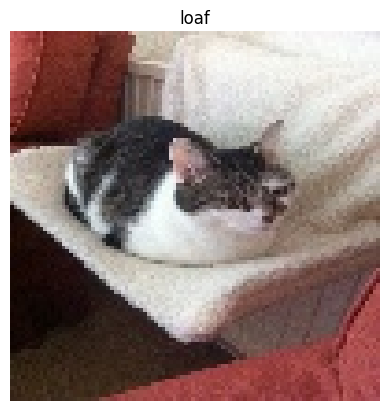

In [2]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Simple transform: resize + tensor
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

# Load dataset: point to the top-level "images" folder
dataset = datasets.ImageFolder(root="images", transform=transform)

print(f"Classes found: {dataset.classes}")  # Should print: ['cat', 'loaf']

# Load an image (cat)
img, label = dataset[0]

# Display it
plt.imshow(img.permute(1, 2, 0).numpy())  # CHW -> HWC
plt.title(dataset.classes[label])
plt.axis('off')
plt.show()

# Load an image (loaf)
img, label = dataset[323]

# Display it
plt.imshow(img.permute(1, 2, 0).numpy())  # CHW -> HWC
plt.title(dataset.classes[label])
plt.axis('off')
plt.show()

### MLP

In [3]:
# =========================
# Multi-layer perceptron on cat vs loaf
# =========================

from __future__ import annotations
from typing import Optional, Tuple, Dict, Any
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T


def set_seed(seed: int) -> None:
    """
    Set seeds for random, numpy, and torch to make results deterministic.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Make cuDNN deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Force PyTorch to use deterministic algorithms (PyTorch >= 1.8)
    torch.use_deterministic_algorithms(True)



from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

def get_catloaf_loaders(batch_size: int, seed: int, train_ratio: float = 0.8):
    g = torch.Generator().manual_seed(seed)

    transform = T.Compose([
        T.Resize((64, 64)),  # keep consistent MLP
        T.RandomHorizontalFlip(),
        T.RandomRotation(10),
        T.ToTensor()
    ])

    full_dataset = ImageFolder(
        root="images", 
        transform=transform
    )

    # Split sizes
    total_size = len(full_dataset)
    train_size = int(train_ratio * total_size)
    test_size = total_size - train_size

    train_dataset, test_dataset = random_split(
        full_dataset,
        [train_size, test_size],
        generator=g  # ensures reproducibility
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=g
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, test_loader



class MLP(nn.Module):
    """
    MLP classifier for cat vs loaf.

    Requirements:
    - Flatten input to (B, 3072)
    - At least two hidden layers
    - ReLU activations
    - Dropout in at least one hidden layer (p provided by constructor)
    - Output logits of shape (B, 2)
    """

    def __init__(self, hidden_sizes=(1024, 512), dropout_p: float = 0.2):
        super().__init__()
        input_dim = 64*64*3
        h1, h2 = hidden_sizes
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        # Hidden layer 1
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        # Hidden layer 2
        x = self.fc2(x)
        x = self.relu(x)
        # Output layer (logits)
        x = self.fc3(x)
        return x
    


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> Dict[str, float]:
    """
    Train for one epoch.

    Returns dict:
      - "loss": float
      - "acc": float
    """
    model.train() 
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        # accumulate metrics
        total_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
    avg_loss = total_loss / total
    accuracy = correct / total
    return {"loss": avg_loss, "acc": accuracy}



@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device: torch.device) -> Dict[str, float]:
    """
    Evaluate model.

    Returns dict:
      - "loss": float
      - "acc": float
    """
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        total_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
    avg_loss = total_loss / total
    accuracy = correct / total
    return {"loss": avg_loss, "acc": accuracy}



if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    set_seed(0)
    train_loader, test_loader = get_catloaf_loaders(batch_size=64, seed=0)
    model = MLP(hidden_sizes=(1024, 512), dropout_p=0.3).to(device)
    opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    for epoch in range(30):
        tr = train_one_epoch(model, train_loader, opt, device)
        te = evaluate(model, test_loader, device)
    print("Final Epoch Train:", tr, "Test:", te)


Final Epoch Train: {'loss': 0.6291892140410668, 'acc': 0.6414728682170543} Test: {'loss': 0.6432951661256644, 'acc': 0.6076923076923076}
